#**IMPORT LIBRARIES**

In [16]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Display Settings

In [17]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',120)

##Visualization Style

In [18]:
sns.set_theme(style='darkgrid')

#**LOAD DATASET**

In [19]:
health_connect = pd.read_csv('HealthConnect_Appointment_Data.csv')

In [20]:
print(health_connect.head())

  appointment_id patient_id  gender  age age_group         appointment_type booking_date appointment_date  \
0       HC-00001     P-1613  Female   39     35-44                Follow-up     2/6/2025        2/18/2025   
1       HC-00002     P-0813    Male   31     25-34  Specialist Consultation    2/25/2026        2/27/2026   
2       HC-00003     P-1366  Female   50     45-54     General Consultation   11/16/2025       12/24/2025   
3       HC-00004     P-1031    Male   59     55-64                Follow-up    7/18/2025        8/28/2025   
4       HC-00005     P-1458  Female   34     25-34                Follow-up     7/9/2025        8/25/2025   

  appointment_day appointment_time  booking_lead_days  previous_appointments  previous_no_shows reminder_sent  \
0         Tuesday        Afternoon                 12                      2                  0           Yes   
1          Friday          Morning                  2                      6                  0           Yes   
2     

#**Dataset Overview**

In [21]:
print(health_connect.shape)
print('\nColumn names:')
for number, column in enumerate(health_connect.columns, 1):
  print(f'{number}. {column}')

(5000, 18)

Column names:
1. appointment_id
2. patient_id
3. gender
4. age
5. age_group
6. appointment_type
7. booking_date
8. appointment_date
9. appointment_day
10. appointment_time
11. booking_lead_days
12. previous_appointments
13. previous_no_shows
14. reminder_sent
15. reminder_channel
16. distance_to_clinic_km
17. waiting_time_minutes
18. appointment_outcome


#**Data Types**

In [22]:
data_types = pd.DataFrame({'Column': health_connect.columns, 'Data Type': health_connect.dtypes.astype(str).values,'Uniques Values':[health_connect[column].nunique(dropna=True) for column in health_connect.columns],'Missing Values':[health_connect[column].isna().sum() for column in health_connect.columns]})
display(data_types)

,Column,Data Type,Uniques Values,Missing Values
0,appointment_id,object,5000,0
1,patient_id,object,1696,0
2,gender,object,3,0
3,age,int64,63,0
4,age_group,object,6,0
5,appointment_type,object,4,0
6,booking_date,object,593,0
7,appointment_date,object,545,0
8,appointment_day,object,7,0
9,appointment_time,object,3,0


**Data Types:** Variables such as Age, Booking Lead Days, and Previous no shows are stored as integers; Distance to clinic and waiting time in minutes are stored as decimals, while the rest are stored as texts.

**Missing Values:** Reminder channel column has 1366 missing values, distance to clinic has 90 missing values, and waiting time has 60 missing values



#**Missing Value Analysis**

In [23]:
missing_summary = pd.DataFrame({'Column':health_connect.columns,'Missing_Count':[health_connect[column].isna().sum() for column in health_connect.columns],'Missing_Percentage':[round(health_connect[column].isna().mean()*100,2)for column in health_connect.columns]})
missing_summary = missing_summary.sort_values(by='Missing_Percentage',ascending=False)
display(missing_summary)

,Column,Missing_Count,Missing_Percentage
14,reminder_channel,1366,27.32
15,distance_to_clinic_km,90,1.80
16,waiting_time_minutes,60,1.20
0,appointment_id,0,0.00
1,patient_id,0,0.00
2,gender,0,0.00
6,booking_date,0,0.00
3,age,0,0.00
4,age_group,0,0.00
5,appointment_type,0,0.00


Missing Values: Reminder channel column has 1366 missing values, distance to clinic has 90 missing values, and waiting time has 60 missing values

#**Duplicate Analysis**

In [24]:
duplicate_count = health_connect.duplicated().sum()
print(f'Duplicate rows:{duplicate_count:,}')
print(f'Duplicate percentage:'f'{duplicate_count/len(health_connect)*100:.2f}%')

Duplicate rows:0
Duplicate percentage:0.00%


There are no duplicate rows

#**Numerical Analysis**

In [25]:
numeric_column = health_connect.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric columns:{numeric_column}')
if numeric_column:
  display(health_connect[numeric_column].describe().T)

Numeric columns:['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes']


,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.794800,18.138547,18.0,33.0,49.0,64.0,80.0
booking_lead_days,5000.0,29.638600,17.399360,0.0,15.0,30.0,45.0,60.0
previous_appointments,5000.0,3.013800,1.741211,0.0,2.0,3.0,4.0,11.0
previous_no_shows,5000.0,0.544200,0.746832,0.0,0.0,0.0,1.0,5.0
distance_to_clinic_km,4910.0,10.109572,6.590030,0.5,5.3,8.7,13.5,45.0
waiting_time_minutes,4940.0,24.189676,10.863184,2.0,17.0,24.0,32.0,68.0


#Categorical Analysis

In [26]:
categorical_column = health_connect.select_dtypes(include=['object','category','bool']).columns.tolist()
print(f'Categorical columns:{categorical_column}')
for column in categorical_column:
  print('='*70)
  print(f'Column:{column}')
  print(f'Unique Values:{health_connect[column].nunique(dropna = True)}')
  if health_connect[column].nunique(dropna=True) <= 30:
    display(health_connect[column].value_counts(dropna=False).to_frame('count').T)

Categorical columns:['appointment_id', 'patient_id', 'gender', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'appointment_outcome']
Column:appointment_id
Unique Values:5000
Column:patient_id
Unique Values:1696
Column:gender
Unique Values:3


gender,Female,Male,Prefer not to say
count,2488,2404,108


Column:age_group
Unique Values:6


age_group,65+,35-44,55-64,45-54,25-34,18-24
count,1241,819,800,793,783,564


Column:appointment_type
Unique Values:4


...

reminder_sent,Yes,No
count,3634,1366


Column:reminder_channel
Unique Values:3


reminder_channel,SMS,NaN,WhatsApp,Email
count,2000,1366,1101,533


Column:appointment_outcome
Unique Values:3


appointment_outcome,No-Show,Attended,Cancelled
count,2423,2314,263


#Check numerical variables for outliers

In [48]:
print("\n\nNUMERICAL VARIABLE OUTLIER CHECK")
print("=" * 50)
numeric_column = health_connect.select_dtypes(include="number").columns
for col in numeric_column:
    Q1 = health_connect[col].quantile(0.25)
    Q3 = health_connect[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = health_connect[(health_connect[col] < lower_bound) | (health_connect[col] > upper_bound)]
    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of potential outliers: {len(outliers)}")




NUMERICAL VARIABLE OUTLIER CHECK

age
Q1: 33.0
Q3: 64.0
IQR: 31.0
Lower bound: -13.5
Upper bound: 110.5
Number of potential outliers: 0

booking_lead_days
Q1: 15.0
Q3: 45.0
IQR: 30.0
Lower bound: -30.0
Upper bound: 90.0
Number of potential outliers: 0

previous_appointments
Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower bound: -1.0
Upper bound: 7.0
Number of potential outliers: 64

previous_no_shows
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower bound: -1.5
Upper bound: 2.5
Number of potential outliers: 93

distance_to_clinic_km
Q1: 5.3
Q3: 13.5
IQR: 8.2
Lower bound: -6.999999999999999
Upper bound: 25.799999999999997
Number of potential outliers: 148

waiting_time_minutes
Q1: 17.0
Q3: 32.0
IQR: 15.0
Lower bound: -5.5
Upper bound: 54.5
Number of potential outliers: 19


#Summary table of numerical variables

In [28]:
print("\n\nNUMERICAL SUMMARY")
print("=" * 50)
numerical_summary = health_connect[numeric_column].describe().T
numerical_summary["missing"] = health_connect[numeric_column].isnull().sum()
display(numerical_summary)



NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max,missing
age,5000.0,48.794800,18.138547,18.0,33.0,49.0,64.0,80.0,0
booking_lead_days,5000.0,29.638600,17.399360,0.0,15.0,30.0,45.0,60.0,0
previous_appointments,5000.0,3.013800,1.741211,0.0,2.0,3.0,4.0,11.0,0
previous_no_shows,5000.0,0.544200,0.746832,0.0,0.0,0.0,1.0,5.0,0
distance_to_clinic_km,4910.0,10.109572,6.590030,0.5,5.3,8.7,13.5,45.0,90
waiting_time_minutes,4940.0,24.189676,10.863184,2.0,17.0,24.0,32.0,68.0,60


#Check for impossible numerical values

In [29]:
print("\n\nCHECKING FOR IMPOSSIBLE NUMERICAL VALUES")
print("=" * 50)
for col in numeric_column:
    print(f"\n--- {col} ---")
    print("Minimum:", health_connect[col].min())
    print("Maximum:", health_connect[col].max())



CHECKING FOR IMPOSSIBLE NUMERICAL VALUES

--- age ---
Minimum: 18
Maximum: 80

--- booking_lead_days ---
Minimum: 0
Maximum: 60

--- previous_appointments ---
Minimum: 0
Maximum: 11

--- previous_no_shows ---
Minimum: 0
Maximum: 5

--- distance_to_clinic_km ---
Minimum: 0.5
Maximum: 45.0

--- waiting_time_minutes ---
Minimum: 2.0
Maximum: 68.0


#Check whether numerical variables have very different scales

In [30]:
print("\n\nNUMERICAL VARIABLE RANGES")
print("=" * 50)
scale_check = pd.DataFrame({"Minimum": health_connect[numeric_column].min(),"Maximum": health_connect[numeric_column].max(),"Range": health_connect[numeric_column].max() - health_connect[numeric_column].min()})
display(scale_check)



NUMERICAL VARIABLE RANGES


,Minimum,Maximum,Range
age,18.0,80.0,62.0
booking_lead_days,0.0,60.0,60.0
previous_appointments,0.0,11.0,11.0
previous_no_shows,0.0,5.0,5.0
distance_to_clinic_km,0.5,45.0,44.5
waiting_time_minutes,2.0,68.0,66.0


#Create an EDA issue summary

In [31]:
print("\n\nPOTENTIAL PREPROCESSING ISSUES TO REVIEW IN WEEK 5")
print("=" * 50)
print("""
1. Data types:
   Check whether variables have the correct data type.

2. Categorical consistency:
   Check for inconsistent spelling, capitalisation and categories.

3. Extra spaces:
   Check categorical variables for leading/trailing spaces.

4. Outliers:
   Review potential outliers in numerical variables before deciding
   whether they require treatment.

5. Invalid values:
   Investigate values that appear impossible or unrealistic.

6. High-cardinality categorical variables:
   Review variables containing many unique categories.

7. Variable scaling:
   Review numerical variables with substantially different ranges
   before deciding whether scaling is required.""")



POTENTIAL PREPROCESSING ISSUES TO REVIEW IN WEEK 5

1. Data types:
   Check whether variables have the correct data type.

2. Categorical consistency:
   Check for inconsistent spelling, capitalisation and categories.

3. Extra spaces:
   Check categorical variables for leading/trailing spaces.

4. Outliers:
   Review potential outliers in numerical variables before deciding
   whether they require treatment.

5. Invalid values:
   Investigate values that appear impossible or unrealistic.

6. High-cardinality categorical variables:
   Review variables containing many unique categories.
   
7. Variable scaling:
   Review numerical variables with substantially different ranges
   before deciding whether scaling is required.


#Find Appointment Outcome Column

In [32]:
outcome_col = 'appointment_outcome'
print('Appointment outcomes:')
print(health_connect[outcome_col].value_counts(dropna=False))

Appointment outcomes:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


#Appointment Percentage

In [33]:
outcome_distribution = (health_connect[outcome_col].value_counts(dropna=False, normalize=True).mul(100).round(2))
print('Appointment Outcome Distribution(%):')
display(outcome_distribution)

Appointment Outcome Distribution(%):


,proportion
appointment_outcome,
No-Show,48.46
Attended,46.28
Cancelled,5.26


#Visualization

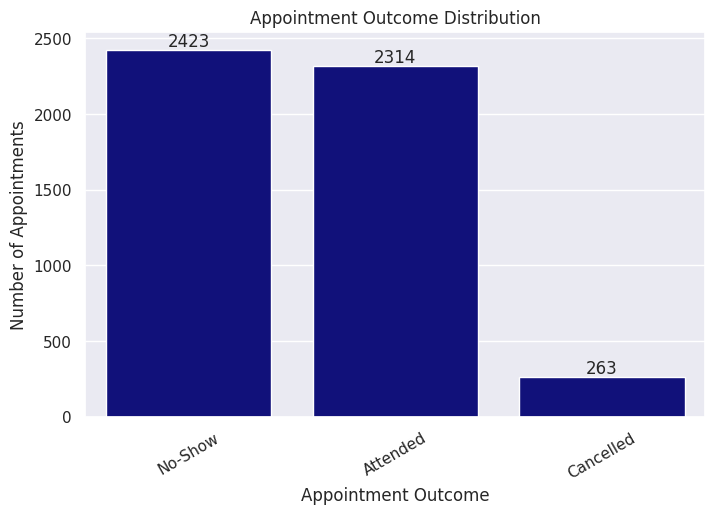

In [34]:
plt.figure(figsize=(8,5))
ax=sns.countplot(data=health_connect, x=outcome_col,order= health_connect['appointment_outcome'].value_counts().index,color = 'darkblue')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Appointment Outcome Distribution')
plt.xlabel('Appointment Outcome')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=30)
plt.show()

#Modelling Dataset

In [35]:
model_outcomes = ['Attended','No-Show']
model_health_connect = health_connect[health_connect['appointment_outcome'].isin(model_outcomes)].copy()
model_health_connect['no_show'] = (model_health_connect['appointment_outcome']== 'No-Show').astype(int)
print('Health Connect:',len(health_connect))
print('Rows used for primary no_show model:',len(model_health_connect))
print('Rows excluded because of cancellation/other outcomes:',len(health_connect)-len(model_health_connect))
display(model_health_connect['no_show'].value_counts().rename(index ={0:'Attended',1:'No-Show'}).to_frame('Count'))

Health Connect: 5000
Rows used for primary no_show model: 4737
Rows excluded because of cancellation/other outcomes: 263


,Count
no_show,
No-Show,2423
Attended,2314


#Checking Class Imbalance

In [36]:
target_distribution = (model_health_connect['no_show'].value_counts(normalize=True).mul(100).round(2))
print('Target Distribution(%):')
display(target_distribution)

Target Distribution(%):


,proportion
no_show,
1,51.15
0,48.85


#**Feature Analysis**

The purpose of the feature analysis is to determine which variables may be
useful to a future no-show prediction model.

In [37]:
def profile_feature(data, column):
    result = {"Feature": column, "Data Type": str(data[column].dtype), "Rows": len(data), "Missing Count": data[column].isna().sum(), "Missing Percentage": round(data[column].isna().mean() * 100,2),"Unique Values": data[column].nunique(dropna=True)}
    if pd.api.types.is_numeric_dtype(data[column]):
        result["Mean"] = data[column].mean()
        result["Median"] = data[column].median()
        result["Min"] = data[column].min()
        result["Max"] = data[column].max()
    else:
        result["Mean"] = np.nan
        result["Median"] = np.nan
        result["Min"] = np.nan
        result["Max"] = np.nan
    return result

In [38]:
feature_profile = pd.DataFrame([profile_feature(health_connect, column)for column in health_connect.columns])
display(feature_profile)

,Feature,Data Type,Rows,Missing Count,Missing Percentage,Unique Values,Mean,Median,Min,Max
0,appointment_id,object,5000,0,0.00,5000,NaN,NaN,NaN,NaN
1,patient_id,object,5000,0,0.00,1696,NaN,NaN,NaN,NaN
2,gender,object,5000,0,0.00,3,NaN,NaN,NaN,NaN
3,age,int64,5000,0,0.00,63,48.794800,49.0,18.0,80.0
4,age_group,object,5000,0,0.00,6,NaN,NaN,NaN,NaN
5,appointment_type,object,5000,0,0.00,4,NaN,NaN,NaN,NaN
6,booking_date,object,5000,0,0.00,593,NaN,NaN,NaN,NaN
7,appointment_date,object,5000,0,0.00,545,NaN,NaN,NaN,NaN
8,appointment_day,object,5000,0,0.00,7,NaN,NaN,NaN,NaN
9,appointment_time,object,5000,0,0.00,3,NaN,NaN,NaN,NaN


#Feature recommendation framework

Potential features will be classified into four categories.

### Recommended

Variables with strong business relevance, reasonable data quality and a
clear possibility of being available before the appointment.

### Recommended With Caution

Variables that may provide useful information but require additional
investigation because of missing data, timing, fairness, interpretability or
other concerns.

### Investigate Further

Variables for which the available evidence is insufficient to recommend
immediate inclusion.

### Exclude

Variables that are likely to cause target leakage, represent the outcome
directly, occur after the prediction point, or otherwise should not be used
for prediction.

In [39]:
feature_recommendations = pd.DataFrame([{"Feature": "Previous no-shows","Business Relevance": "High","Potential Predictive Value": "High","Data Quality": "To assess","Available Before Appointment": "Yes, if historical","Leakage Risk": "Low","Recommendation": "Recommended","Reason": "Previous attendance behaviour may provide useful information about future appointment attendance."},
    {"Feature": "Reminder information","Business Relevance": "High","Potential Predictive Value": "Potentially High","Data Quality": "To assess","Available Before Appointment": "Depends on reminder timing","Leakage Risk": "Medium","Recommendation": "Recommended With Caution","Reason": "Reminder history may be informative, but the exact timing of the reminder must be considered."},
    {"Feature": "Distance to clinic","Business Relevance": "Medium/High","Potential Predictive Value": "Potentially Useful","Data Quality": "To assess","Available Before Appointment": "Yes","Leakage Risk": "Low","Recommendation": "Recommended With Caution","Reason": "Accessibility and travel distance may influence appointment attendance."},
    {"Feature": "Waiting time","Business Relevance": "High","Potential Predictive Value": "Potentially Useful","Data Quality": "To assess","Available Before Appointment": "Yes, if calculated from booking and appointment dates","Leakage Risk": "Low","Recommendation": "Recommended","Reason": "Longer waiting periods may be associated with appointment attendance behaviour."},
    {"Feature": "Previous appointment outcomes","Business Relevance": "High","Potential Predictive Value": "High","Data Quality": "To assess","Available Before Appointment": "Yes, if historical","Leakage Risk": "Low/Medium","Recommendation": "Recommended With Caution","Reason": "Historical appointment behaviour may help identify attendance patterns."}])
display(feature_recommendations)

,Feature,Business Relevance,Potential Predictive Value,Data Quality,Available Before Appointment,Leakage Risk,Recommendation,Reason
0,Previous no-shows,High,High,To assess,"Yes, if historical",Low,Recommended,Previous attendance behaviour may provide usef...
1,Reminder information,High,Potentially High,To assess,Depends on reminder timing,Medium,Recommended With Caution,"Reminder history may be informative, but the e..."
2,Distance to clinic,Medium/High,Potentially Useful,To assess,Yes,Low,Recommended With Caution,Accessibility and travel distance may influenc...
3,Waiting time,High,Potentially Useful,To assess,"Yes, if calculated from booking and appointmen...",Low,Recommended,Longer waiting periods may be associated with ...
4,Previous appointment outcomes,High,High,To assess,"Yes, if historical",Low/Medium,Recommended With Caution,Historical appointment behaviour may help iden...


#Feature Scoring

In [40]:
feature_scoring = pd.DataFrame([{"Feature": "Previous no-shows","Business Relevance": 5,"Potential Predictive Value": 5,"Data Quality": 3,"Availability": 5,"Leakage Risk": 5,"Overall Recommendation": "Recommended"},
    {"Feature": "Reminder information","Business Relevance": 5,"Potential Predictive Value": 4,"Data Quality": 3,"Availability": 3,"Leakage Risk": 3,"Overall Recommendation": "Recommended With Caution"},
    {"Feature": "Distance to clinic","Business Relevance": 4,"Potential Predictive Value": 4,"Data Quality": 3,"Availability": 5,"Leakage Risk": 5,"Overall Recommendation": "Recommended With Caution"},
    {"Feature": "Waiting time","Business Relevance": 5,"Potential Predictive Value": 4,"Data Quality": 4,"Availability": 5,"Leakage Risk": 5,"Overall Recommendation": "Recommended"},
    {"Feature": "Previous appointment outcomes","Business Relevance": 5,"Potential Predictive Value": 5,"Data Quality": 3,"Availability": 5,"Leakage Risk": 4,"Overall Recommendation": "Recommended With Caution"}])
score_columns = ["Business Relevance","Potential Predictive Value","Data Quality","Availability","Leakage Risk"]
feature_scoring["Total Score"] = feature_scoring[score_columns].sum(axis=1)
feature_scoring = feature_scoring.sort_values("Total Score",ascending=False)
display(feature_scoring)


,Feature,Business Relevance,Potential Predictive Value,Data Quality,Availability,Leakage Risk,Overall Recommendation,Total Score
0,Previous no-shows,5,5,3,5,5,Recommended,23
3,Waiting time,5,4,4,5,5,Recommended,23
4,Previous appointment outcomes,5,5,3,5,4,Recommended With Caution,22
2,Distance to clinic,4,4,3,5,5,Recommended With Caution,21
1,Reminder information,5,4,3,3,3,Recommended With Caution,18


#Feature vs analysis outcome

In [41]:
def numerical_feature_vs_outcome(data,feature,outcome):
    if feature not in data.columns:
        print(f"{feature} not found.")
        return
    if outcome not in data.columns:
        print(f"{outcome} not found.")
        return
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data,x=outcome,y=feature)
    plt.title(f"{feature} by Appointment Outcome")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()



In [42]:
def categorical_feature_vs_outcome(data,feature,outcome):
    if feature not in data.columns:
        print(f"{feature} not found.")
        return
    if outcome not in data.columns:
        print(f"{outcome} not found.")
        return
    cross_tab = pd.crosstab(data[feature],data[outcome],normalize="index") * 100
    display(cross_tab.round(2))
    cross_tab.plot(kind="bar",stacked=True,figsize=(10, 6))
    plt.title(f"{feature} vs Appointment Outcome")
    plt.ylabel("Percentage")
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.legend(title=outcome)
    plt.tight_layout()
    plt.show()


#Correlation Analysis

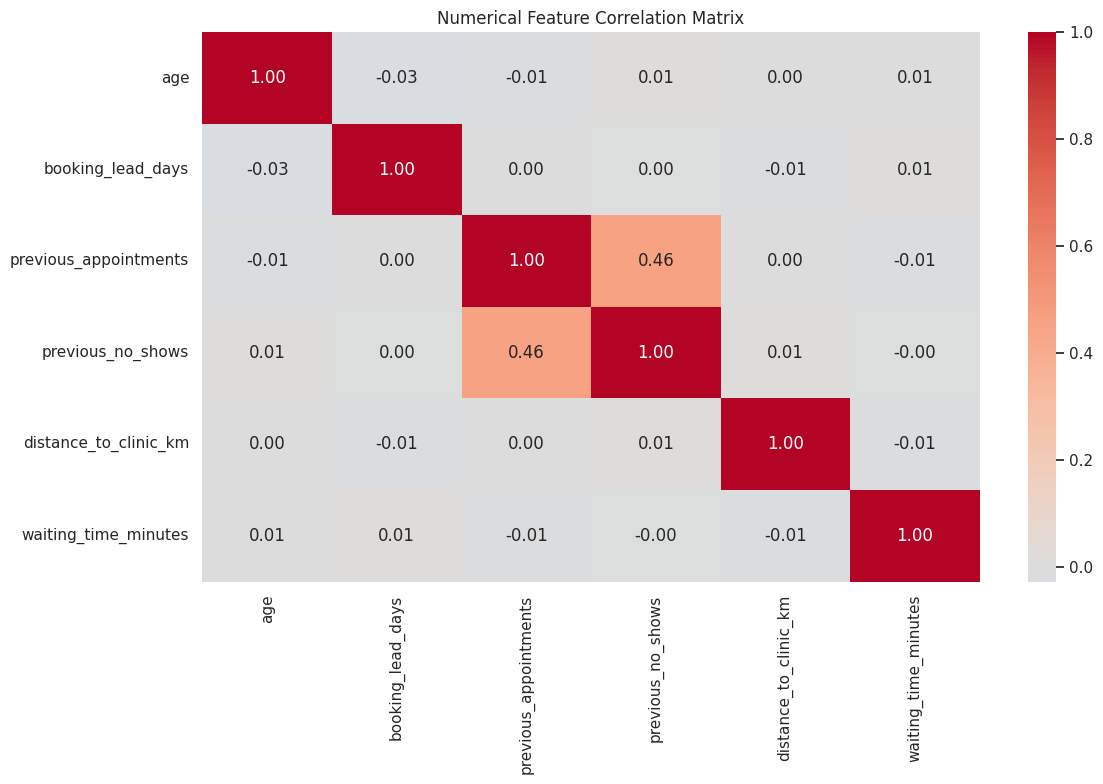

In [43]:
numeric_health_connect = health_connect.select_dtypes(include=np.number)
if numeric_health_connect.shape[1] > 1:
    correlation_matrix = numeric_health_connect.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)
    plt.title("Numerical Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

#Leakage Assessment

In [44]:
leakage_register = pd.DataFrame([
    {"Variable Type": "Final appointment outcome","Leakage Risk": "High","Reason": "The outcome is the information being predicted.","Recommendation": "Exclude"},
    {"Variable Type": "Post-appointment administrative information","Leakage Risk": "High","Reason": "Information may only become available after the appointment.","Recommendation": "Exclude"},
    {"Variable Type": "Historical appointment behaviour","Leakage Risk": "Low","Reason": "Historical information can be available before a future appointment.", "Recommendation": "Consider"},
    {"Variable Type": "Booking information","Leakage Risk": "Low","Reason": "Booking information can generally exist before the appointment.","Recommendation": "Consider"},
    {"Variable Type": "Reminder information","Leakage Risk": "Medium","Reason": "Suitability depends on when the reminder information becomes available.","Recommendation": "Review timing"}])
display(leakage_register)


,Variable Type,Leakage Risk,Reason,Recommendation
0,Final appointment outcome,High,The outcome is the information being predicted.,Exclude
1,Post-appointment administrative information,High,Information may only become available after th...,Exclude
2,Historical appointment behaviour,Low,Historical information can be available before...,Consider
3,Booking information,Low,Booking information can generally exist before...,Consider
4,Reminder information,Medium,Suitability depends on when the reminder infor...,Review timing


#Appointment Handling Outcome

In [49]:
appointment_outcome_policy = {
    "No-show": "Target class: appointment did not occur because the patient did not attend.",
    "Attended": "Target class: appointment was attended.",
    "Cancelled by patient": "Exclude from the no-show target because the patient cancelled rather than failed to attend.",
    "Cancelled by clinic": "Exclude from the no-show target because the appointment was cancelled by the healthcare provider.",
    "Rescheduled": "Handle according to the final appointment outcome; do not treat a rescheduled appointment as a no-show unless the appointment was actually missed.",
    "Unknown/Missing outcome": "Review and exclude from modelling if the outcome cannot be reliably determined."}
display(appointment_outcome_policy)

{'No-show': 'Target class: appointment did not occur because the patient did not attend.',
 'Attended': 'Target class: appointment was attended.',
 'Cancelled by patient': 'Exclude from the no-show target because the patient cancelled rather than failed to attend.',
 'Cancelled by clinic': 'Exclude from the no-show target because the appointment was cancelled by the healthcare provider.',
 'Rescheduled': 'Handle according to the final appointment outcome; do not treat a rescheduled appointment as a no-show unless the appointment was actually missed.',
 'Unknown/Missing outcome': 'Review and exclude from modelling if the outcome cannot be reliably determined.'}

#Final Recommended Variables For Analysis

In [46]:
final_feature_recommendations = pd.DataFrame([{"Priority": 1,"Feature Group": "Historical Attendance","Candidate Features": "Previous no-shows; previous attendance; previous appointment outcomes","Recommendation": "HIGH PRIORITY","Reason": "Directly relevant to historical attendance behaviour."},
    {"Priority": 2,"Feature Group": "Appointment Timing","Candidate Features": "Waiting time; booking-to-appointment interval; appointment day/time","Recommendation": "HIGH PRIORITY","Reason": "Timing and scheduling may influence attendance."},
    {"Priority": 3,"Feature Group": "Reminder Information","Candidate Features": "Reminder sent; reminder type; reminder timing","Recommendation": "HIGH PRIORITY WITH TIMING CHECK","Reason": "Potentially useful for understanding engagement, but prediction timing must be defined."},
    {"Priority": 4,"Feature Group": "Accessibility","Candidate Features": "Distance to clinic; relevant accessibility variables","Recommendation": "MEDIUM/HIGH PRIORITY","Reason": "Accessibility may influence appointment attendance."},
    {"Priority": 5,"Feature Group": "Appointment and Booking","Candidate Features": "Appointment type; booking method; scheduling characteristics","Recommendation": "MEDIUM PRIORITY","Reason": "Different appointment contexts may have different attendance patterns."},
    {"Priority": 6,"Feature Group": "Post-Outcome Information","Candidate Features": "Final outcome; post-appointment status; post-outcome records","Recommendation": "EXCLUDE","Reason": "High risk of target leakage."}])
display(final_feature_recommendations)


,Priority,Feature Group,Candidate Features,Recommendation,Reason
0,1,Historical Attendance,Previous no-shows; previous attendance; previo...,HIGH PRIORITY,Directly relevant to historical attendance beh...
1,2,Appointment Timing,Waiting time; booking-to-appointment interval;...,HIGH PRIORITY,Timing and scheduling may influence attendance.
2,3,Reminder Information,Reminder sent; reminder type; reminder timing,HIGH PRIORITY WITH TIMING CHECK,Potentially useful for understanding engagemen...
3,4,Accessibility,Distance to clinic; relevant accessibility var...,MEDIUM/HIGH PRIORITY,Accessibility may influence appointment attend...
4,5,Appointment and Booking,Appointment type; booking method; scheduling c...,MEDIUM PRIORITY,Different appointment contexts may have differ...
5,6,Post-Outcome Information,Final outcome; post-appointment status; post-o...,EXCLUDE,High risk of target leakage.
